In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [2]:
cleaned_data = pd.read_csv("../data_folder/cleaned_data.csv")

In [3]:
cleaned_data.head(2)

,Order_Date,Season,Country,Category,Sub_Category,Product_Name,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days,Payment_Method,Month
0,2023-01-18,Winter,Mexico,Electronics,Smartphones,Xiaomi 13,520.40,7,0.00,3642.80,2444.11,1198.69,32.91,2.25,4,Google Pay,January
1,2023-11-13,Fall,USA,Books & Media,Books,Thinking Fast and Slow,22.59,2,0.25,33.88,28.32,5.56,16.41,4.72,5,Credit Card,November


## reviewing our cleaned data

In [4]:
cleaned_data.describe()

,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days
count,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,236.307452,2.731300,0.17675,528.438770,384.674939,143.763831,23.648594,32.299889,11.436100
std,380.901351,2.038508,0.16167,1154.811538,828.069100,420.487992,21.496639,28.424003,5.347633
min,10.010000,1.000000,0.00000,5.330000,4.850000,-1572.900000,-50.000000,2.000000,3.000000
25%,42.767500,1.000000,0.00000,67.227500,50.017500,9.007500,13.497500,8.260000,7.000000
50%,92.495000,2.000000,0.15000,164.600000,121.395000,34.745000,28.330000,20.300000,10.000000
75%,221.822500,4.000000,0.30000,469.952500,339.020000,118.475000,39.082500,50.362500,15.000000
max,2497.760000,10.000000,0.50000,19966.500000,15729.670000,9144.150000,54.990000,99.990000,25.000000


In [5]:
cleaned_data.shape

(10000, 17)

In [6]:
cleaned_data["Revenue"].sum()

np.float64(5284387.699999999)

In [7]:
cleaned_data["Profit"].sum()

np.float64(1437638.31)

## Profit Exploratory Analysis

1) finding out which country generated the highest Profit

In [8]:
country_profit = cleaned_data.groupby("Country")["Profit"].sum().sort_values(ascending=False)

country_profit

Country
USA             123170.72
Mexico          122543.90
Canada          121002.80
Egypt           103930.99
Jordan           85073.63
India            79751.95
France           78543.11
Italy            77982.55
Japan            74848.58
China            73762.21
Kuwait           71643.56
Saudi Arabia     66937.98
Singapore        65263.04
Spain            61976.48
UK               59212.52
Germany          58269.90
UAE              56936.69
South Korea      56787.70
Name: Profit, dtype: float64

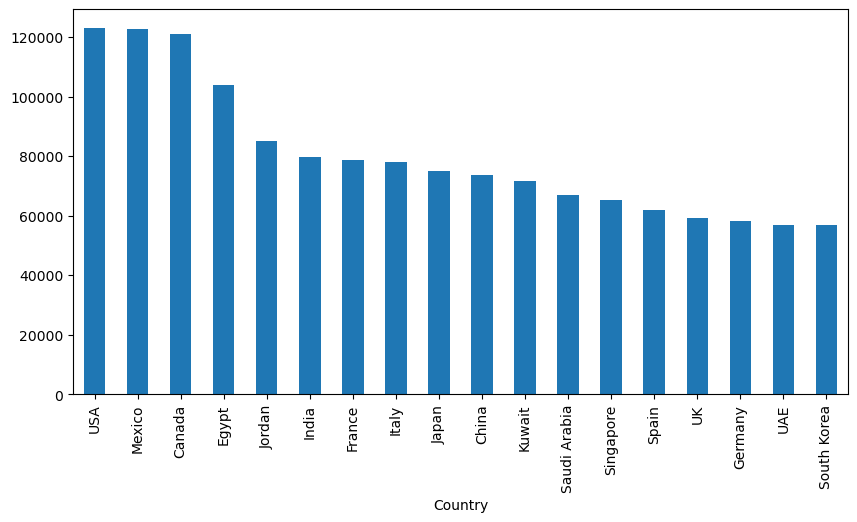

In [9]:
# visualization of the highest country profit

country_profit.plot(kind="bar", figsize = (10,5))

plt.title = ("Countries by Profit")
plt.xlabel = ("Countries")
plt.ylabel = ("Profit")
plt.show()

** NOTE ** : USA generated the highest profit

# Sub-category product with highest profitability

In [10]:
profit_by_sub_category = cleaned_data.groupby("Sub_Category")["Profit"].sum().sort_values(ascending=False)

profit_by_sub_category

Sub_Category
Laptops          446773.61
Smartphones      227872.08
Tablets          195392.04
Furniture        125162.63
Software          89844.78
Appliances        74022.00
Headphones        55410.42
Footwear          50856.61
Women's Wear      38329.19
Skincare          33349.90
Kitchen Tools     33236.82
Men's Wear        26519.49
Supplements       25675.83
Books             15192.91
Name: Profit, dtype: float64

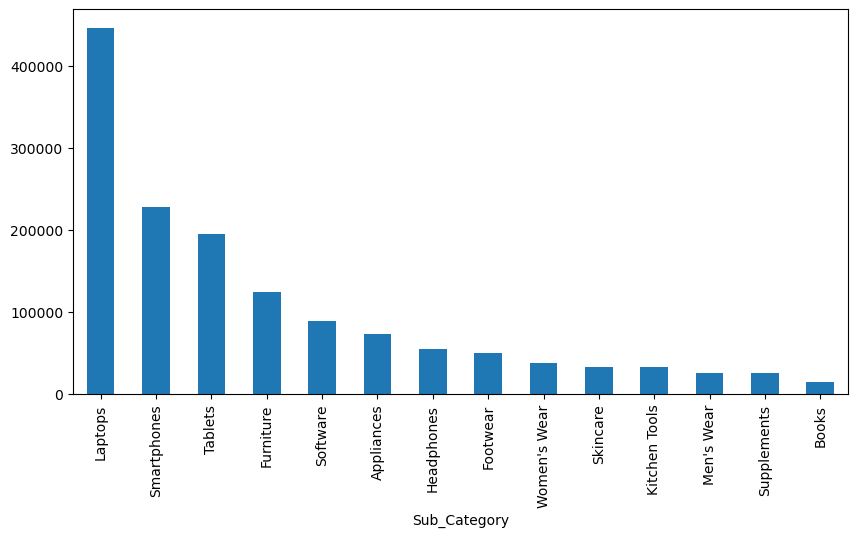

In [11]:
profit_by_sub_category.plot(kind="bar", figsize = (10,5))

plt.xlabel = ("Region")
plt.ylabel = ("Revenue")
plt.show()

**Note: Laptops are the most profitable Sub-Category product **

In [12]:
cleaned_data.head(2)

,Order_Date,Season,Country,Category,Sub_Category,Product_Name,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days,Payment_Method,Month
0,2023-01-18,Winter,Mexico,Electronics,Smartphones,Xiaomi 13,520.40,7,0.00,3642.80,2444.11,1198.69,32.91,2.25,4,Google Pay,January
1,2023-11-13,Fall,USA,Books & Media,Books,Thinking Fast and Slow,22.59,2,0.25,33.88,28.32,5.56,16.41,4.72,5,Credit Card,November


In [13]:
cleaned_data["Order_Date"] = pd.to_datetime(cleaned_data["Order_Date"])

In [14]:
# Profit by year

cleaned_data["Year"] = cleaned_data["Order_Date"].dt.year

profit_by_year = cleaned_data.groupby("Year")["Profit"].sum()

profit_by_year

Year
2021    148531.05
2022    356104.57
2023    625276.12
2024    307726.57
Name: Profit, dtype: float64

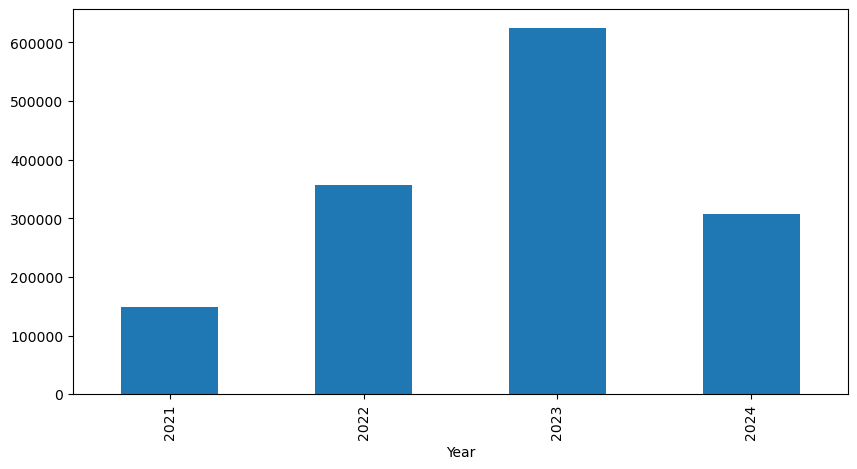

In [15]:
profit_by_year.plot(kind="bar", figsize = (10, 5))

plt.xlabel = ("Year")
plt.ylabel = ("Revenue")
plt.show()

** Note: the year 2023 has the highest Profit **


In [16]:
# Profit by month
cleaned_data["Month"] = cleaned_data["Order_Date"].dt.month

profit_by_month = cleaned_data.groupby("Month")["Profit"].sum().sort_values(ascending=False)
profit_by_month

Month
8     137566.36
1     134130.82
10    133623.96
3     127871.65
7     125397.97
11    122059.99
5     118514.67
9     113064.65
12    111532.11
4     109580.58
6     103761.36
2     100534.19
Name: Profit, dtype: float64

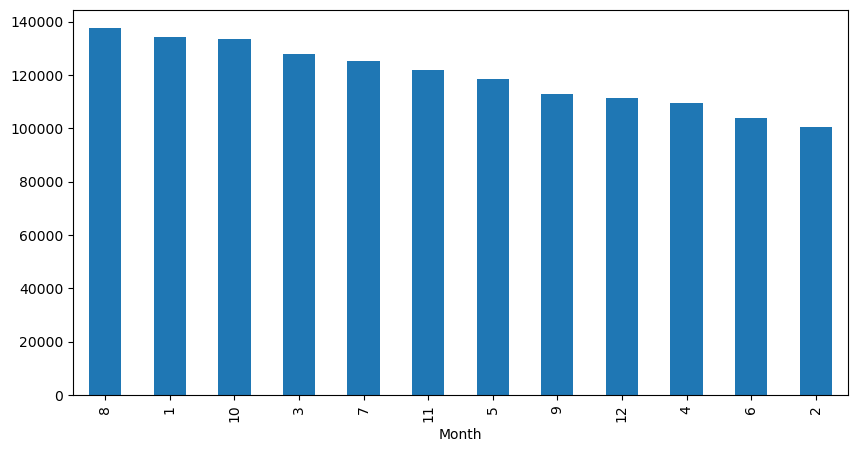

In [17]:
profit_by_month.plot(kind="bar", figsize = (10, 5))

plt.xlabel = ("Month")
plt.ylabel = ("Profit")
plt.show()

** Note: October is the month with the highest profit

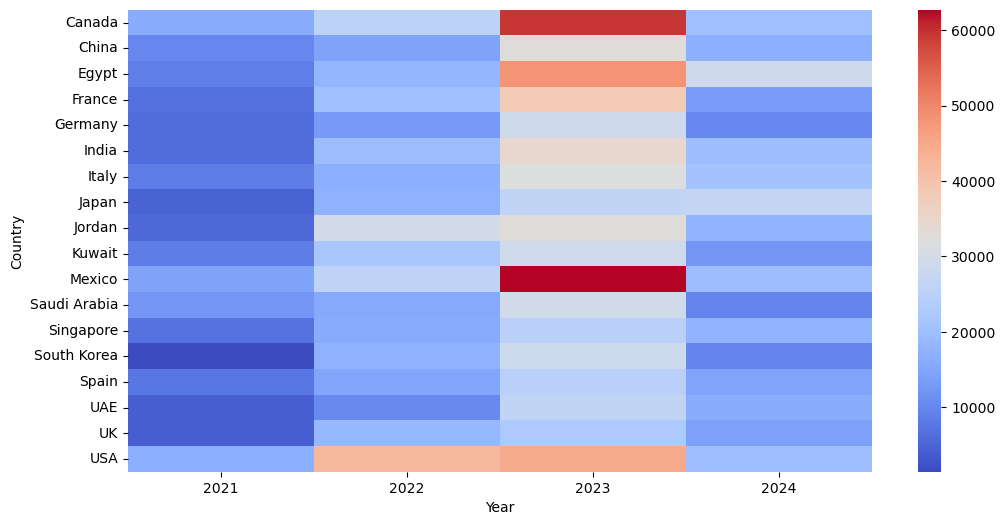

In [18]:
## showing the relationship between year, country and profit

year_country_profit = cleaned_data.pivot_table(
    index="Country",
    columns="Year",
    values="Profit",
    aggfunc="sum"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    year_country_profit,
    cmap="coolwarm",
    annot=False,   # change to True if you want numbers
    fmt=".0f"
)

plt.title = ("Profit Heatmap (Country vs Year)")
plt.ylabel = ("Country")
plt.xlabel = ("Year")

plt.show()

** Mexico has the highest profitability in the year 2023.

In [19]:
## most profitable product
def profit_analysis(x, y):
    result = cleaned_data.groupby(x)[y].sum().sort_values(ascending=False)
    return result

profitable_product = profit_analysis("Product_Name", "Profit")
profitable_product

Product_Name
Lenovo ThinkPad X1         100584.09
MacBook Air M2              97941.48
Dell XPS 15                 89052.11
HP Spectre x360             89029.69
ASUS ZenBook                70166.24
                             ...    
Atomic Habits                3403.63
Rich Dad Poor Dad            3049.67
Deep Work                    3015.08
The Psychology of Money      2951.70
Thinking Fast and Slow       2772.83
Name: Profit, Length: 70, dtype: float64

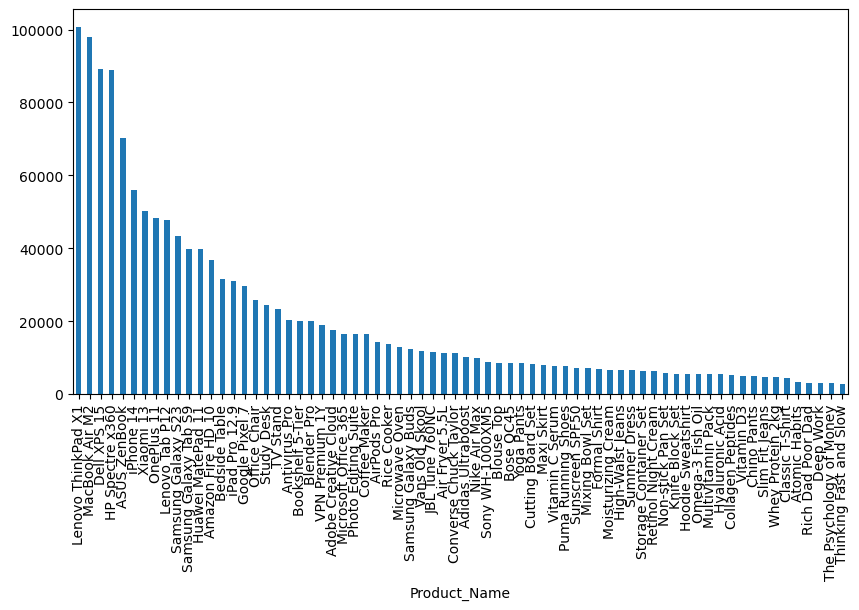

In [20]:
profitable_product.plot(kind = "bar", figsize = (10,5))

plt.xlabel= ("SubCategory")
plt.ylabel= ("Quantity")
plt.show();

** Lenovo thinkpad x1 is the most profitable product**

## Product exploratory Analysis

In [21]:
def product_analysis(x, y):
    result = cleaned_data.groupby(x)[y].sum().sort_values(ascending=False)
    return result

product_quantity = product_analysis("Sub_Category", "Quantity")
product_quantity

Sub_Category
Skincare         2967
Software         2848
Books            2819
Supplements      2482
Appliances       1945
Women's Wear     1862
Furniture        1796
Kitchen Tools    1794
Men's Wear       1783
Footwear         1730
Smartphones      1398
Laptops          1326
Tablets          1302
Headphones       1261
Name: Quantity, dtype: int64

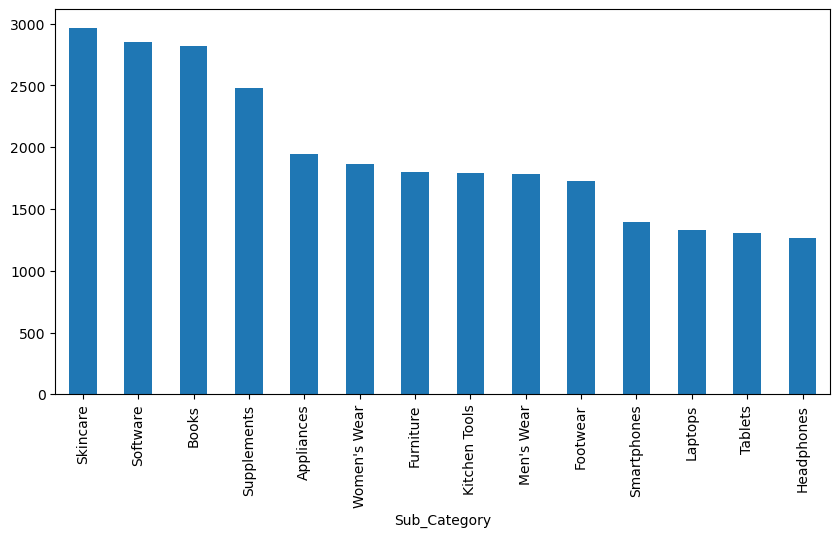

In [22]:
product_quantity.plot(kind = "bar", figsize = (10,5))

plt.xlabel= ("SubCategory")
plt.ylabel= ("Quantity")
plt.show();

** Note: Skin care product is the product with the highest quantity purchased ***

In [23]:
cleaned_data.head(3)

,Order_Date,Season,Country,Category,Sub_Category,Product_Name,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days,Payment_Method,Month,Year
0,2023-01-18,Winter,Mexico,Electronics,Smartphones,Xiaomi 13,520.40,7,0.00,3642.80,2444.11,1198.69,32.91,2.25,4,Google Pay,1,2023
1,2023-11-13,Fall,USA,Books & Media,Books,Thinking Fast and Slow,22.59,2,0.25,33.88,28.32,5.56,16.41,4.72,5,Credit Card,11,2023
2,2022-04-28,Spring,Canada,Electronics,Headphones,Bose QC45,241.30,1,0.00,241.30,161.41,79.89,33.11,13.28,8,Credit Card,4,2022


In [24]:
cleaned_data.columns

Index(['Order_Date', 'Season', 'Country', 'Category', 'Sub_Category',
       'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost',
       'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Days',
       'Payment_Method', 'Month', 'Year'],
      dtype='object')

In [25]:
## product name in skin care that has the the highest amount of purchase


skindata_product = cleaned_data[cleaned_data["Sub_Category"] == "Skincare"].groupby("Product_Name")["Quantity"].sum().sort_values(ascending = False)
skindata_product

Product_Name
Vitamin C Serum        662
Sunscreen SPF50        636
Moisturizing Cream     590
Retinol Night Cream    570
Hyaluronic Acid        509
Name: Quantity, dtype: int64

** Vitamin C Serum is the skin care product with the highest quantity"""

## Exploratory Analysis Results
1) USA generated the highest Profit.
2) Laptops are the most profitable subcategory.
3) The year 2023 has the highest Profit
4) October is the month with the highest profit
5) Mexico has the highest profitability in the year 2023.
6) Lenovo thinkpad x1 is the most profitable product
7) Skin care product is the product with the highest quantity purchased
8) Vitamin C Serum is the skin care product with the highest quantity

In [27]:
cleaned_data.to_csv("../data_folder/explored_data.csv")